# exp-h0-faithful-reproduction-01

H2-S의 H0가 기준보다 낮아 비교가 무효였으므로, exp013/014의 안전 H0를 `gs` 내부 self-contained 코드로 재현하는 감사 실행입니다.

- seed42, Stratified 5-fold
- exp013: G+B+V+T+R+A-pair+S + gene×event-type 5-fold cross-fitted enrichment/표준화
- exp014: balanced multiclass LGBM, fold-train 자동 유사쌍 2개, predicted-only hard specialist
- 최종 확률: LR 0.80 + specialist LGBM 0.20
- test는 읽지 않으며, H0가 `0.543679 ± 0.001` 밖이면 다음 H1/H2 실행을 차단합니다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
EXP_DIR = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_006'
RUNNER = EXP_DIR / 'common' / 'run_h0_faithful_reproduction.py'
RESULT = EXP_DIR / 'result'
RUN_ID = 'exp-h0-faithful-reproduction-01'
RUN_EXPERIMENT = True
assert RUNNER.exists() and (ROOT / 'data/raw/train.csv').exists()
print({'runner': RUNNER, 'result': RESULT, 'run': RUN_EXPERIMENT})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_h0_faithful_reproduction.py'), 'result': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/result'), 'run': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 전체 CV 전 필수: path/schema/NaN parser/test 미열람/result schema smoke
subprocess.run([sys.executable, str(RUNNER), '--smoke'], check=True)

{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "result_schemas": {"summary": ["convergence_warning_count", "feature_count_mean", "leakage_check", "nan_as_mutation_count", "oof_accuracy", "oof_macro_f1", "reference_delta", "variant"], "fold": ["feature_count", "fold", "macro_f1", "variant"]}}


CompletedProcess(args=['/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/bin/python', '/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_h0_faithful_reproduction.py', '--smoke'], returncode=0)

In [3]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='faithful H0 folds', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('H0 reproduction runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 전체 CV를 실행하지 않았습니다.')

faithful H0 folds: 1line [00:04,  4.74s/line]

[faithful-H0] fold 1/5: feature fit


faithful H0 folds: 2line [02:38, 92.41s/line]

[faithful-H0] fold 2/5: feature fit


faithful H0 folds: 3line [05:36, 131.42s/line]

...

faithful H0 folds: 5line [11:32, 160.13s/line]

[faithful-H0] fold 5/5: feature fit


faithful H0 folds: 6line [14:21, 163.26s/line]

{"reference_oof_macro_f1": 0.543679, "tolerance": 0.001, "observed_oof_macro_f1": 0.5447438599818917, "reference_delta": 0.0010648599818916527, "baseline_reproduced": false, "block_downstream_experiments": true, "decision": "baseline_not_reproduced"}


faithful H0 folds: 6line [14:21, 143.65s/line]


In [4]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
features = pd.read_csv(RESULT / f'{RUN_ID}_seed42_feature_audit.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_reproduction_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False
display(summary)
display(features)
display(pd.DataFrame([audit]))

,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,reference_oof_macro_f1,reference_delta
0,exp013_LR,0.525910,0.529592,8193.2,0,True,0,0.526130,-0.000220
1,exp014_LGBM_hard_specialist,0.493092,0.525722,8193.2,0,True,0,0.492332,0.000760
2,H0_blend_80_20,0.544744,0.555556,8193.2,0,True,0,0.543679,0.001065


,fold,feature_count,burden,variant,amino_pair,topology,enrichment,exact_vocabulary_size,gene_type_vocabulary_size
0,1,8152,3,7,380,8,26,183895,13967
1,2,8195,3,7,380,8,26,180349,13937
2,3,8161,3,7,380,8,26,180745,13884
3,4,8241,3,7,380,8,26,190931,14087
4,5,8217,3,7,380,8,26,184441,13967


,seed,outer_splits,enrichment_inner_splits,blend,reference,runtime_seconds,test_read,fixed_class_gene_mutation_rules,reference_oof_macro_f1,tolerance,observed_oof_macro_f1,reference_delta,baseline_reproduced,block_downstream_experiments,decision
0,42,5,5,"{'lr': 0.8, 'lgbm_hard_specialist': 0.2}",0.543679,859.918706,False,False,0.543679,0.001,0.544744,0.001065,False,True,baseline_not_reproduced


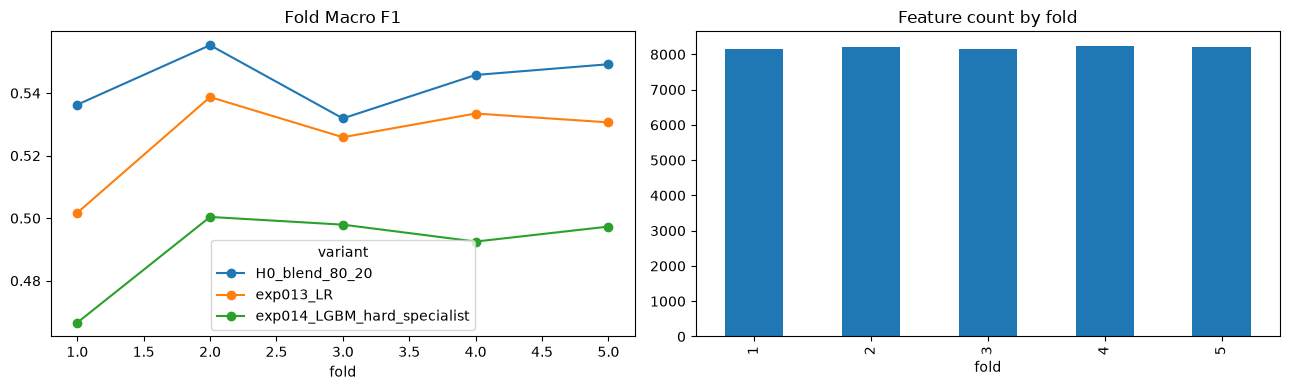

판정: baseline_not_reproduced
기준 H0 미재현: H1/H2-S 실행 금지. feature/fold audit CSV에서 차이를 먼저 확인하세요.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', ax=axes[0], title='Fold Macro F1')
features.set_index('fold').feature_count.plot.bar(ax=axes[1], title='Feature count by fold')
plt.tight_layout(); plt.show()
print('판정:', audit['decision'])
if audit['block_downstream_experiments']:
    print('기준 H0 미재현: H1/H2-S 실행 금지. feature/fold audit CSV에서 차이를 먼저 확인하세요.')